# 03 · Business impact and recommendations
### Turning the modelling result into decisions

This notebook answers the five "business decision-making" expectations in the brief:

1. Key drivers of repeat-loan behaviour
2. Credit and customer-segmentation strategy
3. Retention actions for high-value customers
4. Major risks: data drift, bias, leakage
5. Business impact of model performance shifts (e.g. a drop in recall)

All rupee figures are **per 100,000 customers scored** and use the assumptions in `src/config.py → BUSINESS`.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from src.config import *
from src import plots as P
P.set_style()
pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.max_columns", 30)

from src import impact as I, evaluation as E
f = pd.read_pickle(PROCESSED_DIR / "features.pkl")
scores = pd.read_csv(PROCESSED_DIR / "oot_scores.csv", parse_dates=["application_date"])
metrics = json.loads((MODEL_DIR / "metrics.json").read_text())

B = dict(BUSINESS)
B["avg_ticket_inr"] = float(f.loc[f.approved_amount > 0, "approved_amount"].mean())
BASE_RATE = float(f[TARGET].mean())
N = 100_000
assumptions = pd.Series({
    "Average repeat-loan ticket (from data)": f"₹{B['avg_ticket_inr']:,.0f}",
    "Net contribution margin on disbursal": f"{B['net_margin_on_disbursal']:.0%}",
    "→ Contribution per repeat loan": f"₹{I.contribution_per_repeat(B):,.0f}",
    "Cost of a retention offer (per customer targeted)": f"₹{B['retention_offer_cost_inr']}",
    "Share of reached repeaters whose next loan the offer wins": f"{B['offer_incremental_uplift']:.0%}",
    "Cost to acquire a new customer instead": f"₹{B['new_customer_cac_inr']:,}",
    "Share of base targeted per cycle": f"{B['target_share']:.0%}",
    "Repeat base rate (from data)": f"{BASE_RATE:.1%}",
}, name="value")
assumptions.to_frame()

,value
Average repeat-loan ticket (from data),"₹31,163"
Net contribution margin on disbursal,6%
→ Contribution per repeat loan,"₹1,870"
Cost of a retention offer (per customer targeted),₹150
Share of reached repeaters whose next loan the offer wins,20%
Cost to acquire a new customer instead,"₹1,500"
Share of base targeted per cycle,30%
Repeat base rate (from data),30.1%


## 1. Key drivers of repeat borrowing

**Finding:** in this dataset, **none of the 26 features drives repeat borrowing.**

* Information Value is below 0.001 for every feature (notebook 01).
* Both models are at AUC ≈ 0.50 out-of-time, with permutation p > 0.2 (notebook 02).
* No feature stands clearly apart from a random-noise column.

Found that credit score, income, ticket size, channel, city, device, loan purpose and complaints all show the same ~30% repeat rate.

**What should drive it** (hypotheses to test once the label is validated, based on how digital-lending repeat behaviour normally works):

| Driver | Expected direction | Data needed |
|---|---|---|
| On-time repayment of the first loan | ↑ repeat (and ↑ eligibility) | DPD history / repayment schedule |
| Time since loan closure | Repeat demand peaks in the 30–90 days after closure | Loan closure date |
| Pre-approved offer shown | ↑ repeat | Offer / campaign logs |
| App engagement after disbursal | ↑ repeat | App events, logins |
| Unresolved complaint | ↓ repeat | Ticket status and resolution time, not just the text |
| First-loan product and tenure | Short-tenure consumption loans repeat faster | Product code, tenure |

## 2. Credit and customer-segmentation strategy

Because repeat *propensity* doesn't vary across segments, the segmentation should be built on what *does* vary and matters to the P&L: **credit risk** (bureau band) × **customer value** (ticket size). Repeat propensity is added as a third axis once a valid model exists.

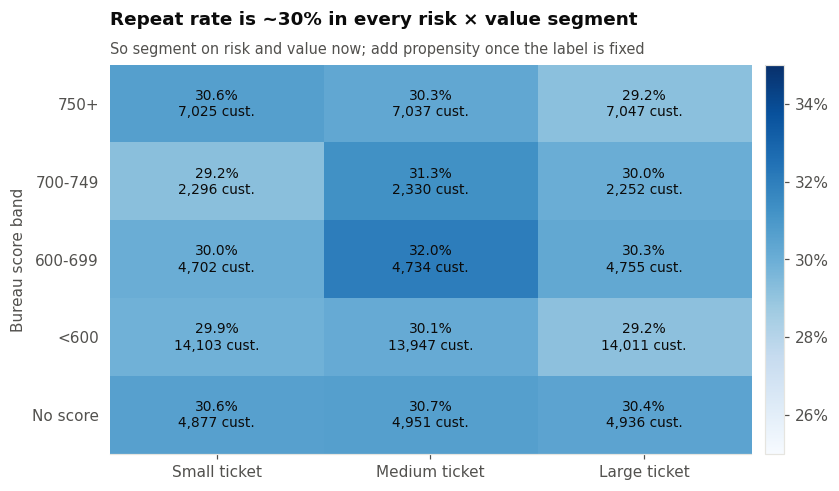

In [2]:
seg = f.groupby(["credit_band", "ticket_band"], observed=True).agg(
    customers=(TARGET, "size"), repeat_rate=(TARGET, "mean"), avg_ticket=("approved_amount", "mean")).reset_index()
rr = seg.pivot(index="credit_band", columns="ticket_band", values="repeat_rate")
cnt = seg.pivot(index="credit_band", columns="ticket_band", values="customers")
rr = rr.reindex(["750+", "700-749", "600-699", "<600", "No score"]); cnt = cnt.reindex(rr.index)

fig, ax = plt.subplots(figsize=(8, 4.6))
im = ax.imshow(rr.values, cmap="Blues", vmin=0.25, vmax=0.35, aspect="auto")
for i in range(rr.shape[0]):
    for j in range(rr.shape[1]):
        v = rr.values[i, j]
        ax.text(j, i, f"{v:.1%}\n{cnt.values[i, j]:,.0f} cust.", ha="center", va="center", fontsize=9,
                color=P.INK)
ax.set_xticks(range(rr.shape[1]), [f"{c} ticket" for c in rr.columns]); ax.set_yticks(range(rr.shape[0]), rr.index)
ax.grid(False); ax.set_ylabel("Bureau score band")
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Repeat rate is ~30% in every risk × value segment", pad=26)
P.subtitle(ax, "So segment on risk and value now; add propensity once the label is fixed")
P.save(fig, "fig12_segment_grid"); plt.show()

In [3]:
policy = pd.DataFrame([
    ["750+",      "Prime",        "Pre-approved top-up at loyalty rate; instant disbursal, no re-KYC", "Up to 1.5× last ticket"],
    ["700-749",   "Near-prime",   "Pre-approved offer at standard rate after 3 on-time EMIs",          "Up to 1.2× last ticket"],
    ["600-699",   "Sub-prime",    "Offer only after full on-time repayment of current loan",           "Same ticket"],
    ["<600",      "High risk",    "No proactive offer; re-assess after 6 on-time EMIs",                "–"],
    ["No score",  "Thin-file",    "Small graduated top-up to build history (growth segment)",          "0.5–1× last ticket"],
], columns=["credit_band", "segment", "repeat-loan strategy", "limit rule"])
size = f.credit_band.value_counts(normalize=True).rename("share_of_base")
policy = policy.merge(size, left_on="credit_band", right_index=True)
policy.style.format({"share_of_base": "{:.0%}"}).hide(axis="index")

credit_band,segment,repeat-loan strategy,limit rule,share_of_base
750+,Prime,"Pre-approved top-up at loyalty rate; instant disbursal, no re-KYC",Up to 1.5× last ticket,21%
700-749,Near-prime,Pre-approved offer at standard rate after 3 on-time EMIs,Up to 1.2× last ticket,7%
600-699,Sub-prime,Offer only after full on-time repayment of current loan,Same ticket,14%
<600,High risk,No proactive offer; re-assess after 6 on-time EMIs,–,42%
No score,Thin-file,Small graduated top-up to build history (growth segment),0.5–1× last ticket,15%


*Note: about 15% of the base has no bureau score.*

## 3. Retention actions for high-value customers

**High-value definition:** bureau band 750+ **and** top-third ticket size **and** top-third income: low risk, high balance, able to service more.

In [4]:
hv = (f.credit_band == "750+") & (f.ticket_band == "Large") & (f.income_band == "High")
hv_stats = pd.Series({
    "high-value customers": hv.sum(),
    "share of base": hv.mean(),
    "share of disbursal": f.loc[hv, "approved_amount"].sum() / f.approved_amount.sum(),
    "avg ticket (HV)": f.loc[hv, "approved_amount"].mean(),
    "repeat rate (HV)": f.loc[hv, TARGET].mean(),
    "repeat rate (rest)": f.loc[~hv, TARGET].mean(),
    "raised a complaint (HV)": f.loc[hv, "has_complaint"].mean(),
})
hv_stats.to_frame("value").style.format(lambda v: f"{v:.1%}" if v < 1 else f"{v:,.0f}")

,value
high-value customers,"2,383"
share of base,2.4%
share of disbursal,3.9%
avg ticket (HV),"50,410"
repeat rate (HV),29.4%
repeat rate (rest),30.1%
raised a complaint (HV),69.4%


In [5]:
lost = (1 - hv_stats["repeat rate (HV)"]) * hv_stats["high-value customers"] / len(f) * N
print(f"Per 100K customers: ~{hv.mean()*N:,.0f} high-value customers, of whom ~{lost:,.0f} do NOT take a second loan.")
print(f"Each retained one is worth ~₹{hv_stats['avg ticket (HV)'] * B['net_margin_on_disbursal']:,.0f} contribution per loan, "
      f"vs ₹{B['new_customer_cac_inr']:,} to acquire a replacement.")

Per 100K customers: ~2,383 high-value customers, of whom ~1,682 do NOT take a second loan.
Each retained one is worth ~₹3,025 contribution per loan, vs ₹1,500 to acquire a replacement.


| # | Action | Why | KPI |
|---|---|---|---|
| 1 | **Pre-approved top-up 30–60 days before the last EMI** | Repeat demand peaks around loan closure | Offer acceptance; time to second loan |
| 2 | **Loyalty pricing** (e.g. 100–200 bps lower) for on-time payers | Price is the main reason prime borrowers switch | Rate-driven attrition |
| 3 | **Zero-friction renewal:** no re-KYC, one-tap disbursal | Prime customers are time-sensitive | Drop-off in the application funnel |
| 4 | **Fix service failures first:** about 70% of applications carry a complaint (app crash, slow processing, errors) | A bad first experience kills the second loan | Complaint rate; resolution SLA |
| 5 | **Relationship manager or priority line** for MSME high-value customers | Working-capital needs recur | MSME repeat rate |

**Measure everything with a randomised holdout.**

In [6]:
rows = []
for mde in [0.02, 0.03, 0.05]:
    rows.append({"detectable uplift": f"+{mde*100:.0f} pts ({BASE_RATE:.0%} → {BASE_RATE+mde:.0%})",
                 "customers per arm": I.ab_sample_size(BASE_RATE, mde)})
pd.DataFrame(rows).style.hide(axis="index")

detectable uplift,customers per arm
+2 pts (30% → 32%),8404
+3 pts (30% → 33%),3767
+5 pts (30% → 35%),1378


*(Two-sided test, α = 0.05, 80% power.)*

## 4. Major risks: leakage, drift, bias

### 4a. Leakage

| Risk | Where | Mitigation used here |
|---|---|---|
| Same customer in train and test | 67% of rows share an ID | GroupKFold by `customer_id` for tuning; out-of-time test |
| Post-decision fields | `approved_amount`, `approval_ratio` | Fine for post-disbursal repeat scoring; **must be removed** for an application-time model (checked: AUC unchanged) |
| Label not fully observed | 2024 applications have < 12 months of follow-up | Restrict training to matured cohorts (≥ 12 months); here the label ignores this, a red flag |
| Timestamp errors | 32% registration after application | `tenure_days` set to missing; root-cause in the pipeline |
| Future information in features | `prior_apps_same_id` | Counts only *earlier* applications |

In [7]:
from src.features import model_matrix
train_mask = f.application_date < pd.Timestamp(OOT_START)
cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
psi_rows = [{"feature": c, "PSI": E.psi(f.loc[train_mask, c], f.loc[~train_mask, c])} for c in cols]
psi_tbl = pd.DataFrame(psi_rows).sort_values("PSI", ascending=False)
psi_tbl["status"] = psi_tbl.PSI.apply(E.psi_label)
psi_tbl.style.format({"PSI": "{:.4f}"}).hide(axis="index")

feature,PSI,status
tenure_days,0.5570,Shifted
prior_apps_same_id,0.4703,Shifted
credit_score,0.0008,Stable
loan_to_income,0.0005,Stable
nb_txn_cnt,0.0005,Stable
approved_amount,0.0005,Stable
age,0.0005,Stable
app_month,0.0004,Stable
income_clean,0.0004,Stable
days_since_last_txn_credit_repayment_24month,0.0004,Stable


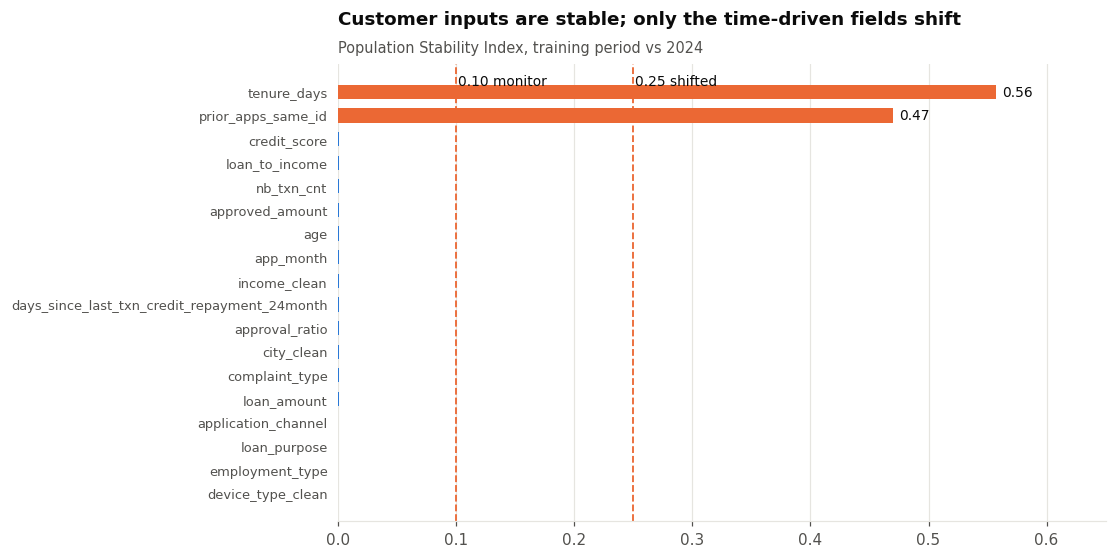

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.4))
pt = psi_tbl.sort_values("PSI")
ax.barh(pt.feature, pt.PSI, color=[P.ORANGE if v >= 0.1 else P.BLUE for v in pt.PSI], height=0.6)
ax.axvline(0.1, color=P.ORANGE, ls="--", lw=1.2); ax.text(0.101, len(pt) - 0.7, "0.10 monitor", fontsize=9)
ax.axvline(0.25, color=P.ORANGE, ls="--", lw=1.2); ax.text(0.251, len(pt) - 0.7, "0.25 shifted", fontsize=9)
for i, v in enumerate(pt.PSI):
    if v >= 0.1:
        ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(0, 0.65); ax.grid(axis="x", color=P.GRID); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=8.5)
ax.set_title("Customer inputs are stable; only the time-driven fields shift", pad=26)
P.subtitle(ax, "Population Stability Index, training period vs 2024")
P.save(fig, "fig13_psi"); plt.show()

**Drift reading:** customer inputs are stable year on year (PSI < 0.1). The only movers are time-driven by construction (`prior_apps_same_id` grows as history accumulates; `tenure_days` lengthens). **Monitoring plan once live:** monthly PSI on inputs and score (alert at 0.1, act at 0.25), monthly AUC/KS on matured cohorts, and a champion–challenger set-up before any recalibration.

In [9]:
test_f = f[~train_mask].reset_index(drop=True)          # same row order as notebook 02's test set
assert (test_f[ID_COL].values == scores[ID_COL].values).all()
sc = pd.concat([scores, test_f[["gender_clean", "city_clean"]]], axis=1)
cut = sc.score_lgbm.quantile(1 - B["target_share"])
sc["selected"] = sc.score_lgbm >= cut
def fairness(col):
    t = sc.groupby(col).agg(customers=("selected", "size"), selection_rate=("selected", "mean"),
                            actual_repeat_rate=(TARGET, "mean"), avg_score=("score_lgbm", "mean"))
    t["ratio_to_max"] = t.selection_rate / t.selection_rate.max()
    return t
g_tbl, c_tbl = fairness("gender_clean"), fairness("city_clean")
display(g_tbl.style.format({"selection_rate": "{:.1%}", "actual_repeat_rate": "{:.1%}", "avg_score": "{:.3f}", "ratio_to_max": "{:.2f}", "customers": "{:,}"}))
display(c_tbl.style.format({"selection_rate": "{:.1%}", "actual_repeat_rate": "{:.1%}", "avg_score": "{:.3f}", "ratio_to_max": "{:.2f}", "customers": "{:,}"}))
print(f"Lowest selection-rate ratio: gender {g_tbl.ratio_to_max.min():.2f}, city {c_tbl.ratio_to_max.min():.2f}  (four-fifths rule flags < 0.80)")

,customers,selection_rate,actual_repeat_rate,avg_score,ratio_to_max
gender_clean,,,,,
Female,"8,271",29.4%,30.3%,0.294,0.97
Male,"8,314",30.3%,30.9%,0.294,1.00
Unknown,"16,635",30.1%,29.7%,0.294,0.99


,customers,selection_rate,actual_repeat_rate,avg_score,ratio_to_max
city_clean,,,,,
Bengaluru,"7,396",29.8%,30.4%,0.295,0.82
Chennai,"3,600",26.6%,30.2%,0.291,0.73
Delhi,"3,683",35.4%,31.3%,0.298,0.97
Hyderabad,"3,780",22.7%,30.4%,0.287,0.62
Jaipur,"3,628",36.5%,30.7%,0.300,1.00
Kolkata,"3,739",31.6%,29.3%,0.296,0.87
Mumbai,"3,710",32.6%,29.4%,0.297,0.89
Pune,"3,684",25.2%,29.2%,0.289,0.69


Lowest selection-rate ratio: gender 0.97, city 0.62  (four-fifths rule flags < 0.80)


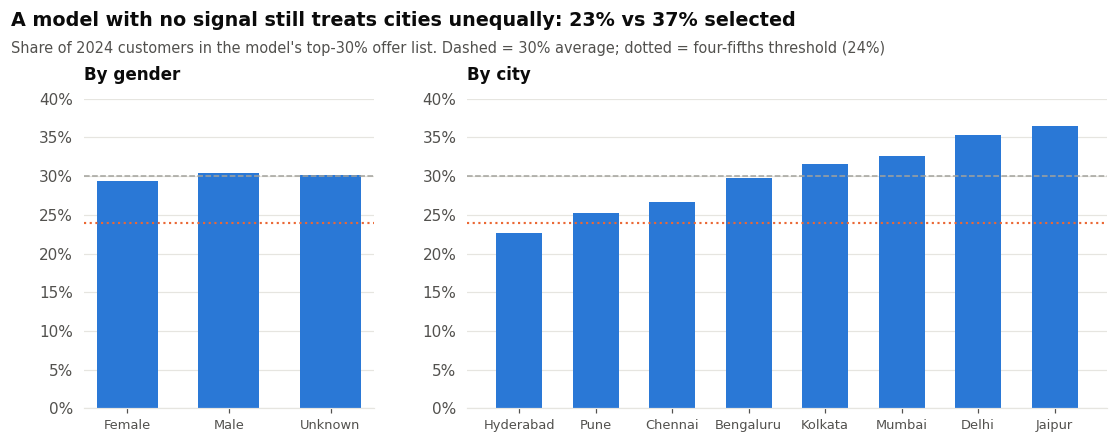

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 2.2], "wspace": 0.2})
for ax, t, title in [(a1, g_tbl, "By gender"), (a2, c_tbl.sort_values("selection_rate"), "By city")]:
    ax.bar(t.index.astype(str), t.selection_rate, color=P.BLUE, width=0.6)
    ax.axhline(B["target_share"], color=P.GREY, ls="--", lw=1)
    ax.axhline(B["target_share"] * 0.8, color=P.ORANGE, ls=":", lw=1.4)
    ax.set_ylim(0, 0.4); P.pct_axis(ax); ax.set_title(title, fontsize=11, loc="left")
    ax.tick_params(axis="x", labelsize=8.5, rotation=0)
fig.subplots_adjust(top=0.78, wspace=0.2)
fig.text(0.07, 0.97, "A model with no signal still treats cities unequally: 23% vs 37% selected",
         ha="left", va="top", fontsize=12.5, fontweight="bold")
fig.text(0.07, 0.905, "Share of 2024 customers in the model's top-30% offer list. Dashed = 30% average; dotted = four-fifths threshold (24%)",
         ha="left", va="top", fontsize=9.5, color=P.INK_2)
P.save(fig, "fig14_fairness"); plt.show()

**Bias to note**

* **Gender:** selection rates are within 3% of each other (ratio 0.97). Gender is excluded from the model, and no proxy effect shows up.
* **City: the model fails the four-fifths rule.** Hyderabad customers would be selected at 23% vs 37% in Jaipur (ratio 0.62), and Pune and Chennai are also below 0.80. Yet **actual repeat rates are identical (29–31%) in every city.** The model learned city-level *noise* and turned it into unequal treatment.

Recommendation based on my current role:

* **Gender stays out of the model** (Fairness and compliance).
* **Proxy check:** city and device can act as proxies for income or community. It should not be present in model.
* **Thin-file customers** (15% with no score) must not be systematically excluded by the model's treatment of missing values.

## 5. What model performance is worth, and what a recall drop costs

### 5a. The value of a model that actually works

Run a retention campaign on the top 30% of customers by score. Recall at that cut-off (the share of all true repeaters we reach) depends on model quality (AUC). The binormal model translates AUC into recall.

In [11]:
vq = I.value_of_model_quality([0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80], N, BASE_RATE, B)
vq_view = vq[["AUC", "capture_rate", "repeaters_reached", "incremental_loans", "incremental_disbursal_inr",
              "gross_contribution_inr", "offer_cost_inr", "net_value_inr", "uplift_vs_random_inr"]]
vq_view.style.format({"AUC": "{:.2f}", "capture_rate": "{:.0%}", "repeaters_reached": "{:,.0f}", "incremental_loans": "{:,.0f}",
                      **{c: (lambda v: f"₹{v/1e5:,.1f} L") for c in ["incremental_disbursal_inr", "gross_contribution_inr",
                                                                  "offer_cost_inr", "net_value_inr", "uplift_vs_random_inr"]}}).hide(axis="index")

AUC,capture_rate,repeaters_reached,incremental_loans,incremental_disbursal_inr,gross_contribution_inr,offer_cost_inr,net_value_inr,uplift_vs_random_inr
0.50,30%,"9,030","1,806",₹562.8 L,₹33.8 L,₹45.0 L,₹-11.2 L,₹0.0 L
0.55,34%,"10,322","2,064",₹643.4 L,₹38.6 L,₹45.0 L,₹-6.4 L,₹4.8 L
0.60,39%,"11,704","2,341",₹729.5 L,₹43.8 L,₹45.0 L,₹-1.2 L,₹10.0 L
0.65,44%,"13,109","2,622",₹817.1 L,₹49.0 L,₹45.0 L,₹4.0 L,₹15.3 L
0.70,48%,"14,581","2,916",₹908.8 L,₹54.5 L,₹45.0 L,₹9.5 L,₹20.8 L
0.75,54%,"16,175","3,235","₹1,008.1 L",₹60.5 L,₹45.0 L,₹15.5 L,₹26.7 L
0.80,59%,"17,882","3,576","₹1,114.5 L",₹66.9 L,₹45.0 L,₹21.9 L,₹33.1 L


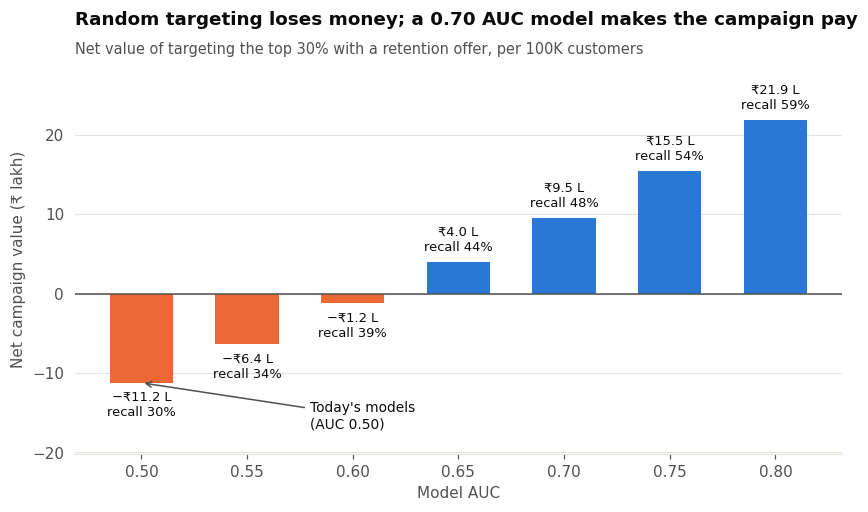

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [P.ORANGE if v < 0 else P.BLUE for v in vq.net_value_inr]
ax.bar(vq.AUC.map(lambda a: f"{a:.2f}"), vq.net_value_inr / 1e5, color=colors, width=0.6)
for i, (v, cap) in enumerate(zip(vq.net_value_inr / 1e5, vq.capture_rate)):
    lab = f"{'−' if v < 0 else ''}₹{abs(v):,.1f} L\nrecall {cap:.0%}"
    ax.text(i, v + (1.0 if v >= 0 else -1.0), lab, ha="center", va="bottom" if v >= 0 else "top", fontsize=8.5)
ax.axhline(0, color=P.INK_2, lw=1)
ax.annotate("Today's models\n(AUC 0.50)", (0, vq.net_value_inr.iloc[0] / 1e5), xytext=(1.6, -17), fontsize=9,
            arrowprops={"arrowstyle": "->", "color": P.INK_2})
ax.set_xlabel("Model AUC"); ax.set_ylabel("Net campaign value (₹ lakh)")
ax.set_ylim(min(vq.net_value_inr / 1e5) - 9, max(vq.net_value_inr / 1e5) + 7)
ax.set_title("Random targeting loses money; a 0.70 AUC model makes the campaign pay", pad=26)
P.subtitle(ax, "Net value of targeting the top 30% with a retention offer, per 100K customers")
P.save(fig, "fig10_value_of_auc"); plt.show()

### 5b. Quantifying a recall drop

Scenario: a production model (AUC ≈ 0.70) reaches **recall R** of true repeaters in its top-30% target list. Data drift then lowers recall by 10 points, so the same budget reaches fewer real repeaters.

In [13]:
r70 = float(vq.loc[np.isclose(vq.AUC, 0.70), "capture_rate"].iloc[0])
drop = I.recall_drop_impact(r70, r70 - 0.10, N, BASE_RATE, B)
fmt = lambda k, v: f"{v:.0%}" if k.startswith("recall") else (f"₹{v/1e5:,.1f} L" if k.endswith("_inr") else f"{v:,.0f}")
pd.Series({k: fmt(k, v) for k, v in drop.items()}).to_frame("per 100K customers")

,per 100K customers
true_repeaters_in_base,"30,070"
recall_from,48%
recall_to,38%
additional_repeaters_missed,"3,007"
disbursal_at_stake_inr,₹937.1 L
contribution_at_stake_inr,₹56.2 L
expected_lost_contribution_inr,₹11.2 L
cac_to_replace_lost_loans_inr,₹9.0 L
offer_spend_wasted_inr,₹4.5 L


In [14]:
sens = []
for upl in [0.10, 0.20, 0.30]:
    for pts in [0.05, 0.10, 0.20]:
        b2 = {**B, "offer_incremental_uplift": upl}
        d = I.recall_drop_impact(r70, r70 - pts, N, BASE_RATE, b2)
        sens.append({"offer win-rate": f"{upl:.0%}", "recall drop": f"−{pts*100:.0f} pts",
                     "expected lost contribution (₹ L)": d.expected_lost_contribution_inr / 1e5,
                     "disbursal at stake (₹ Cr)": d.disbursal_at_stake_inr / 1e7})
sens = pd.DataFrame(sens)
sens.pivot(index="offer win-rate", columns="recall drop", values="expected lost contribution (₹ L)") \
    .style.format("₹{:,.1f} L").set_caption("Expected lost contribution per 100K customers")

recall drop,−10 pts,−20 pts,−5 pts
offer win-rate,,,
10%,₹5.6 L,₹11.2 L,₹2.8 L
20%,₹11.2 L,₹22.5 L,₹5.6 L
30%,₹16.9 L,₹33.7 L,₹8.4 L


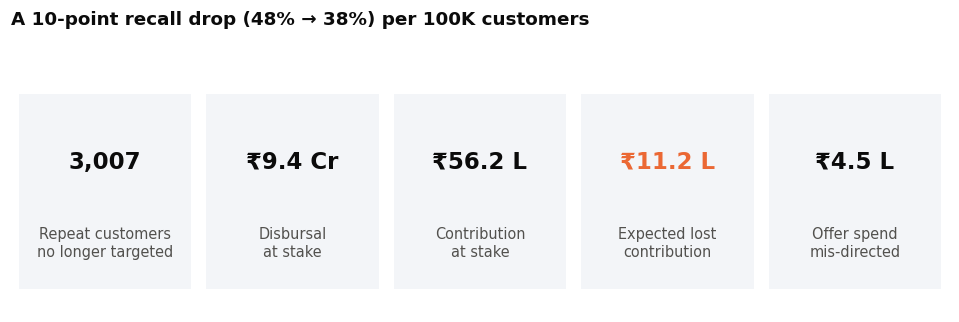

In [15]:
labels = ["Repeat customers\nno longer targeted", "Disbursal\nat stake", "Contribution\nat stake", "Expected lost\ncontribution", "Offer spend\nmis-directed"]
vals = [drop.additional_repeaters_missed, drop.disbursal_at_stake_inr / 1e7, drop.contribution_at_stake_inr / 1e5,
        drop.expected_lost_contribution_inr / 1e5, drop.offer_spend_wasted_inr / 1e5]
txt = [f"{vals[0]:,.0f}", f"₹{vals[1]:,.1f} Cr", f"₹{vals[2]:,.1f} L", f"₹{vals[3]:,.1f} L", f"₹{vals[4]:,.1f} L"]
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off")
for i, (l, t) in enumerate(zip(labels, txt)):
    x = i / len(labels)
    ax.add_patch(plt.Rectangle((x + 0.008, 0.08), 1 / len(labels) - 0.016, 0.72, transform=ax.transAxes,
                               color="#f3f5f8", ec="none"))
    ax.text(x + 0.5 / len(labels), 0.55, t, ha="center", va="center", fontsize=15, fontweight="bold",
            color=P.ORANGE if i == 3 else P.INK, transform=ax.transAxes)
    ax.text(x + 0.5 / len(labels), 0.25, l, ha="center", va="center", fontsize=9.5, color=P.INK_2, transform=ax.transAxes)
ax.set_title(f"A 10-point recall drop ({r70:.0%} → {r70-0.10:.0%}) per 100K customers", pad=10, loc="left")
P.save(fig, "fig11_recall_drop"); plt.show()

**Reading it:** each 1-point fall in recall means about **300 true repeaters per 100K customers drop out of the target list**, putting about **₹94 lakh of repeat disbursal** at stake. How much of that is actually lost depends on how many of those customers the offer would have won (sensitivity table above). That's why the monitoring plan sets **recall at the target cut-off** as a tracked KPI, with an alert when it drops by more than 3 points against the validation level.

*Precision drops cost differently:* offers go to customers who wouldn't repeat. That wastes offer spend and, if offers are pre-approved, extends credit to people the model mis-ranked.

## 6. Recommendations for leadership

1. **Do not deploy either model.** Both rank at random (AUC 0.50). Deploying would spend ₹45 L of offers per 100K customers with returns no better than random targeting, a net loss of about ₹11 L. It would also select customers unevenly by city.
2. **Fix the label first (2–3 weeks):** validate the `customer_id` duplicacy. Rebuild it from loan-level disbursal records.
3. **Add the data that actually predicts repeat borrowing:** first-loan repayment behaviour, loan closure date, offer history, app engagement, complaint resolution.
4. **Run a randomised retention pilot now** on the prime segment (750+, 21% of the base; about 3.8K customers per arm detects a +3 pt uplift). It earns money on low-risk customers *and* creates the causal label for an uplift model.
5. **Segment on risk × value in the meantime** (Section 2 policy). It needs no model and protects credit quality.
6. **Reuse this pipeline:** cleaning, grouped CV, out-of-time test, permutation test, PSI and fairness monitoring are ready for the corrected label.

In [16]:
summary = {
    "avg_ticket_inr": B["avg_ticket_inr"], "contribution_per_repeat_inr": I.contribution_per_repeat(B),
    "value_by_auc": vq[["AUC", "capture_rate", "net_value_inr"]].to_dict(orient="records"),
    "recall_drop": drop.to_dict(), "hv_customers_share": float(hv.mean()),
    "ab_n_per_arm_3pts": I.ab_sample_size(BASE_RATE, 0.03),
    "fairness_min_ratio_gender": float(g_tbl.ratio_to_max.min()), "fairness_min_ratio_city": float(c_tbl.ratio_to_max.min()),
    "max_feature_psi": float(psi_tbl.PSI.max()),
}
(MODEL_DIR / "business_summary.json").write_text(json.dumps(summary, indent=2, default=float))
print(json.dumps({k: v for k, v in summary.items() if k != "value_by_auc"}, indent=1, default=float))

{
 "avg_ticket_inr": 31163.470642303768,
 "contribution_per_repeat_inr": 1869.808238538226,
 "recall_drop": {
  "true_repeaters_in_base": 30070.000000000004,
  "recall_from": 0.48491555037856726,
  "recall_to": 0.3849155503785673,
  "additional_repeaters_missed": 3006.9999999999995,
  "disbursal_at_stake_inr": 93708556.22140741,
  "contribution_at_stake_inr": 5622513.373284445,
  "expected_lost_contribution_inr": 1124502.6746568892,
  "cac_to_replace_lost_loans_inr": 902100.0,
  "offer_spend_wasted_inr": 451049.99999999994
 },
 "hv_customers_share": 0.02383,
 "ab_n_per_arm_3pts": 3767,
 "fairness_min_ratio_gender": 0.9689432004904414,
 "fairness_min_ratio_city": 0.6224477798173943,
 "max_feature_psi": 0.5569844026029817
}
